# Rice Image Dataset CNN and Transfer Learning

This project aims to classify five distinct rice varieties(Arborio, Basmati, İpsala, Jasmine, and Karacadağ)by initial training with custom CNN models, followed by leveraging transfer learning to achieve higher prediction accuracy and superior performance.

<img src='https://media.post.rvohealth.io/wp-content/uploads/2020/08/732x549_THUMBNAIL_Brown_Rice_vs._White_Rice-1-732x549.jpg' width='750'>

### Libraries

In [1]:
import numpy as np           
import pandas as pd          
import os                    
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential       
from tensorflow.keras.utils import to_categorical   
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\furka\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1


### Reading Dataset

In [3]:
img_path=r'C:\Users\furka\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1'

In [4]:
os.listdir(img_path)

['Rice_Image_Dataset']

In [5]:
img_path=r'C:\Users\furka\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset'

In [6]:
os.listdir(img_path)

['Arborio',
 'Basmati',
 'Ipsala',
 'Jasmine',
 'Karacadag',
 'Rice_Citation_Request.txt']

In [7]:
labels=['Karacadag',
 'Basmati',
 'Jasmine',
 'Arborio',
 'Ipsala']

In [8]:
img_list = []
label_list = []

for label in labels:
    for img_file in os.listdir(img_path + '/' + label):
        img_list.append(img_path + '/' + label + '/' + img_file)
        label_list.append(label)

In [9]:
df=pd.DataFrame({'img':img_list,'label':label_list})

### EDA

In [10]:
df.sample(10)


,img,label
40391,C:\Users\furka\.cache\kagglehub\datasets\murat...,Jasmine
35374,C:\Users\furka\.cache\kagglehub\datasets\murat...,Jasmine
60503,C:\Users\furka\.cache\kagglehub\datasets\murat...,Ipsala
23831,C:\Users\furka\.cache\kagglehub\datasets\murat...,Basmati
48791,C:\Users\furka\.cache\kagglehub\datasets\murat...,Arborio
69588,C:\Users\furka\.cache\kagglehub\datasets\murat...,Ipsala
6280,C:\Users\furka\.cache\kagglehub\datasets\murat...,Karacadag
62132,C:\Users\furka\.cache\kagglehub\datasets\murat...,Ipsala
60254,C:\Users\furka\.cache\kagglehub\datasets\murat...,Ipsala
24119,C:\Users\furka\.cache\kagglehub\datasets\murat...,Basmati


In [11]:
d={'Karacadag':0,
 'Basmati':1,
 'Jasmine':2,
 'Arborio':3,
 'Ipsala':4}

In [12]:
df['label_encoded']=df['label'].map(d)

In [13]:
df.sample()

,img,label,label_encoded
54235,C:\Users\furka\.cache\kagglehub\datasets\murat...,Arborio,3


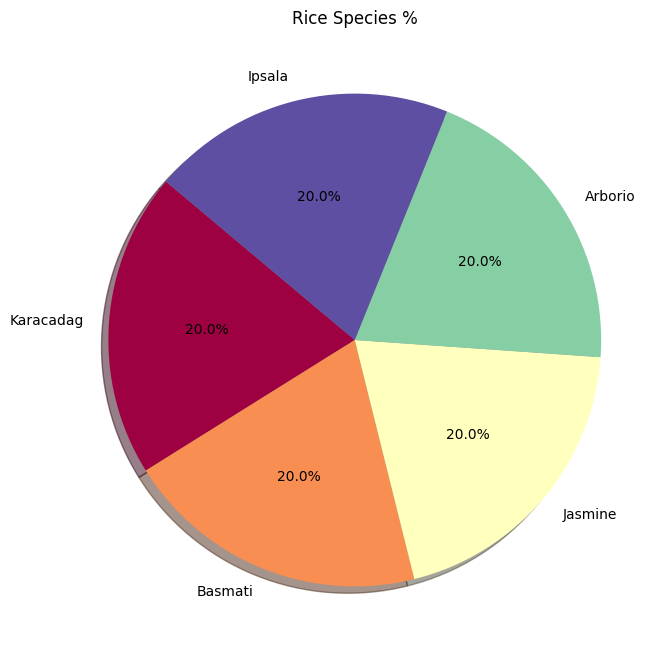

In [14]:
plt.figure(figsize=(10, 8))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', shadow=True, cmap='Spectral', startangle=140)
plt.title("Rice Species %")
plt.ylabel('')
plt.show()

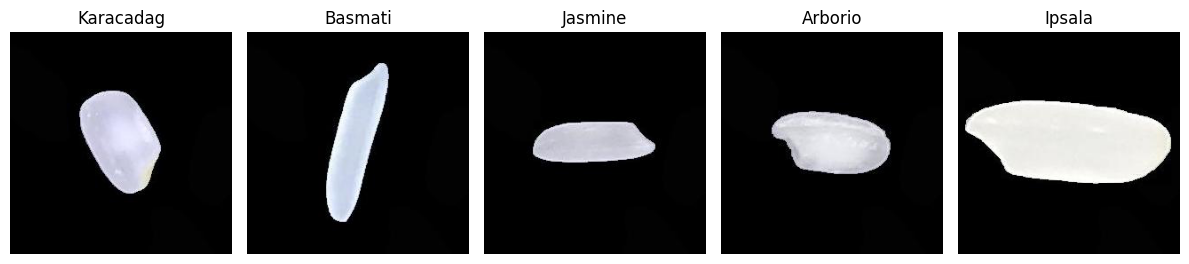

In [15]:
images = []
for label in labels:
    img_path = df[df['label'] == label]['img'].iloc[0]
    image = Image.open(img_path)
    images.append((image, label))
plt.figure(figsize=(12,12))
for i, (image, label) in enumerate(images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(label)    
    plt.axis('off')
plt.tight_layout()
plt.show()

### DATA Processing

In [16]:
x=[]
for img in df['img']:
    img=cv2.imread(str(img))
    img=cv2.resize(img,(64,64))
    img=img/255.0
    x.append(img)

In [17]:
x = np.array(x, dtype=np.float32)

In [18]:
x.shape

(75000, 64, 64, 3)

In [19]:
y=df[['label_encoded']]

### CNN Modelling

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [21]:
from tensorflow.keras.layers import Input
model = Sequential()

model.add(Input(shape=(64,64,3)))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(25, activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [22]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [23]:
history = model.fit(x_train, y_train,validation_data=(x_test, y_test),epochs=12,batch_size=64,callbacks=[early_stop])

Epoch 1/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 1013s 1s/step - accuracy: 0.9177 - loss: 0.3028 - val_accuracy: 0.9813 - val_loss: 0.0697
Epoch 2/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 909s 969ms/step - accuracy: 0.9639 - loss: 0.1067 - val_accuracy: 0.8259 - val_loss: 0.6360
Epoch 3/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 901s 961ms/step - accuracy: 0.9777 - loss: 0.0697 - val_accuracy: 0.9919 - val_loss: 0.0293
Epoch 4/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 896s 955ms/step - accuracy: 0.9786 - loss: 0.0675 - val_accuracy: 0.8587 - val_loss: 0.5412
Epoch 5/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 887s 945ms/step - accuracy: 0.9854 - loss: 0.0477 - val_accuracy: 0.9536 - val_loss: 0.1739
Epoch 6/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 891s 949ms/step - accuracy: 0.9857 - loss: 0.0515 - val_accuracy: 0.5757 - val_loss: 11.4512
Epoch 7/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 893s 952ms/step - accuracy: 0.9871 - loss: 0.0471 - val_accuracy: 0.9765 - val_loss: 0.0783
Epoch 8/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 892s 951ms/step - accuracy: 0.9857 - 

In [25]:
history.history['accuracy'][-1]

0.9856500029563904

In [24]:
model.save("rice_image.keras")

### Model Interpretation

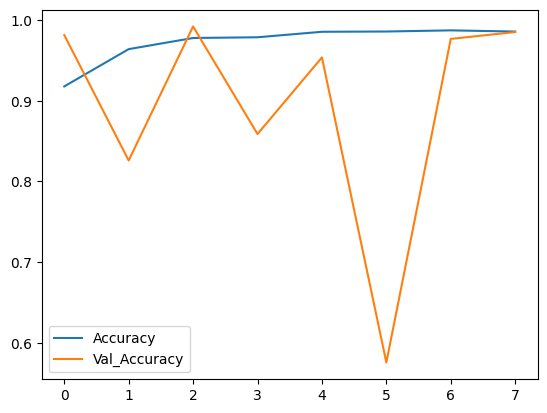

In [26]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val_Accuracy')
plt.legend();

 ### Transfer Learning

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam

In [44]:
data_dir = r'C:\Users\furka\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset'
img_size = 224

train_gen = datagen.flow_from_directory(data_dir, target_size=(img_size, img_size), class_mode='categorical', subset='training', shuffle=True)
val_gen = datagen.flow_from_directory(data_dir, target_size=(img_size, img_size), class_mode='categorical', subset='validation', shuffle=False)

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.


In [45]:
base_model = MobileNetV2(weights='imagenet',include_top=False,input_shape=(img_size, img_size, 3))
base_model.trainable = False

In [46]:
from tensorflow.keras.layers import (Dense,Dropout,GlobalAveragePooling2D)

model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [47]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [48]:
history2=model.fit(train_gen,epochs=50,validation_data=val_gen, callbacks=[early_stop])

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1427s 759ms/step - accuracy: 0.9583 - loss: 0.1268 - val_accuracy: 0.9841 - val_loss: 0.0523
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1510s 806ms/step - accuracy: 0.9829 - loss: 0.0536 - val_accuracy: 0.9882 - val_loss: 0.0406
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1533s 818ms/step - accuracy: 0.9856 - loss: 0.0436 - val_accuracy: 0.9871 - val_loss: 0.0410
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1593s 850ms/step - accuracy: 0.9876 - loss: 0.0377 - val_accuracy: 0.9881 - val_loss: 0.0386
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1525s 813ms/step - accuracy: 0.9889 - loss: 0.0333 - val_accuracy: 0.9874 - val_loss: 0.0391
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1438s 767ms/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.9894 - val_loss: 0.0328
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1514s 808ms/step - accuracy: 0.9909 - loss: 0.0277 - val_accuracy: 0.9906 - val_loss: 0.0298
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1383s 738ms/s

In [59]:
history2.history['accuracy'][-1]

0.994949996471405

In [49]:
model.save("rice_image_transferlearning.keras")

### Model Interprattaion for Transfer Learning

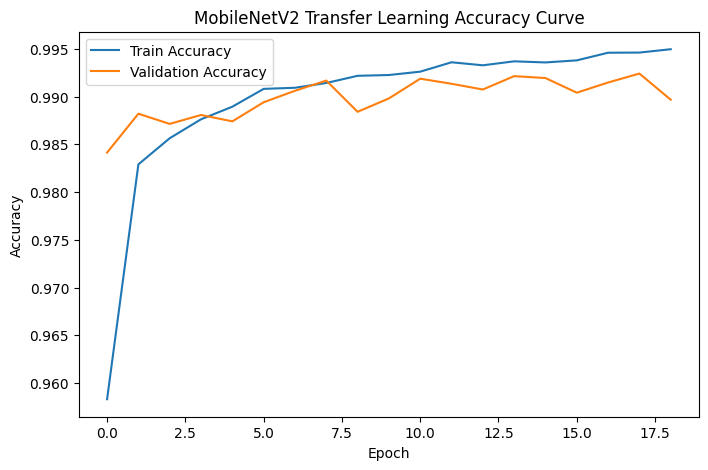

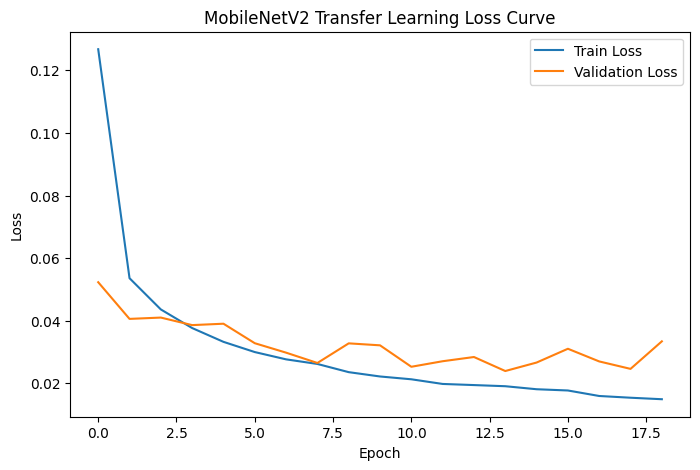

In [50]:
# Accurancy
plt.figure(figsize=(8,5))
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.title("MobileNetV2 Transfer Learning Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Transfer Learning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Confusion Matrix Transfer Learning

469/469 ━━━━━━━━━━━━━━━━━━━━ 302s 642ms/step


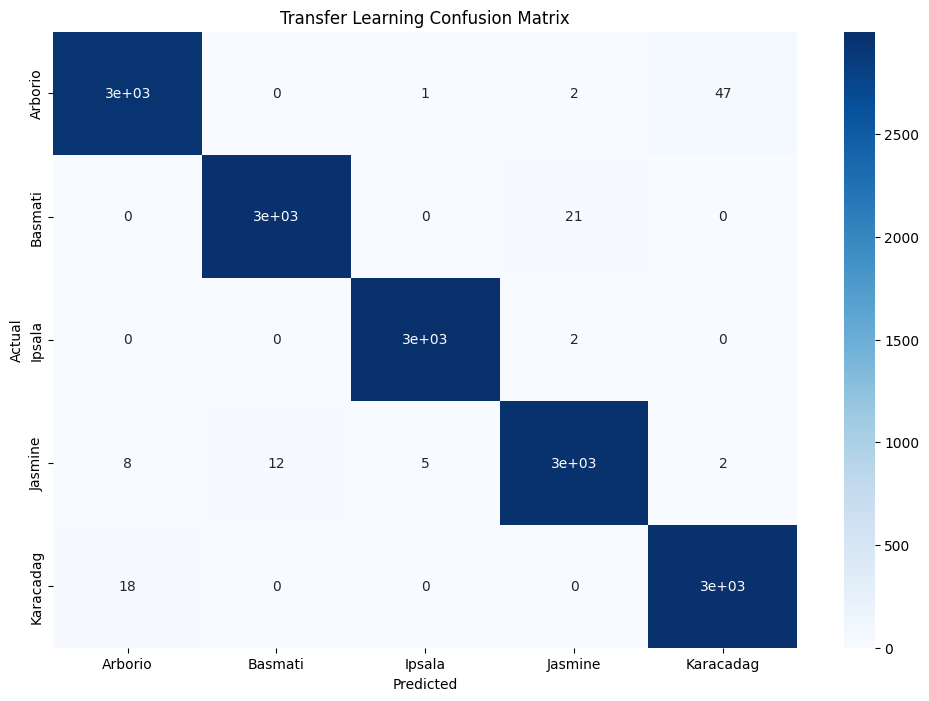

In [51]:
import seaborn as sns
tahmin = model.predict(val_gen)
tahmin = np.argmax(tahmin, axis=1)

y_test = val_gen.classes

labels = list(val_gen.class_indices.keys())

plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_test, tahmin),annot=True,cmap='Blues',xticklabels=labels,yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transfer Learning Confusion Matrix")
plt.show()

In [52]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,233,297 (16.15 MB)

 Trainable params: 658,437 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 1,316,876 (5.02 MB)

### Conclusion &Evaluation

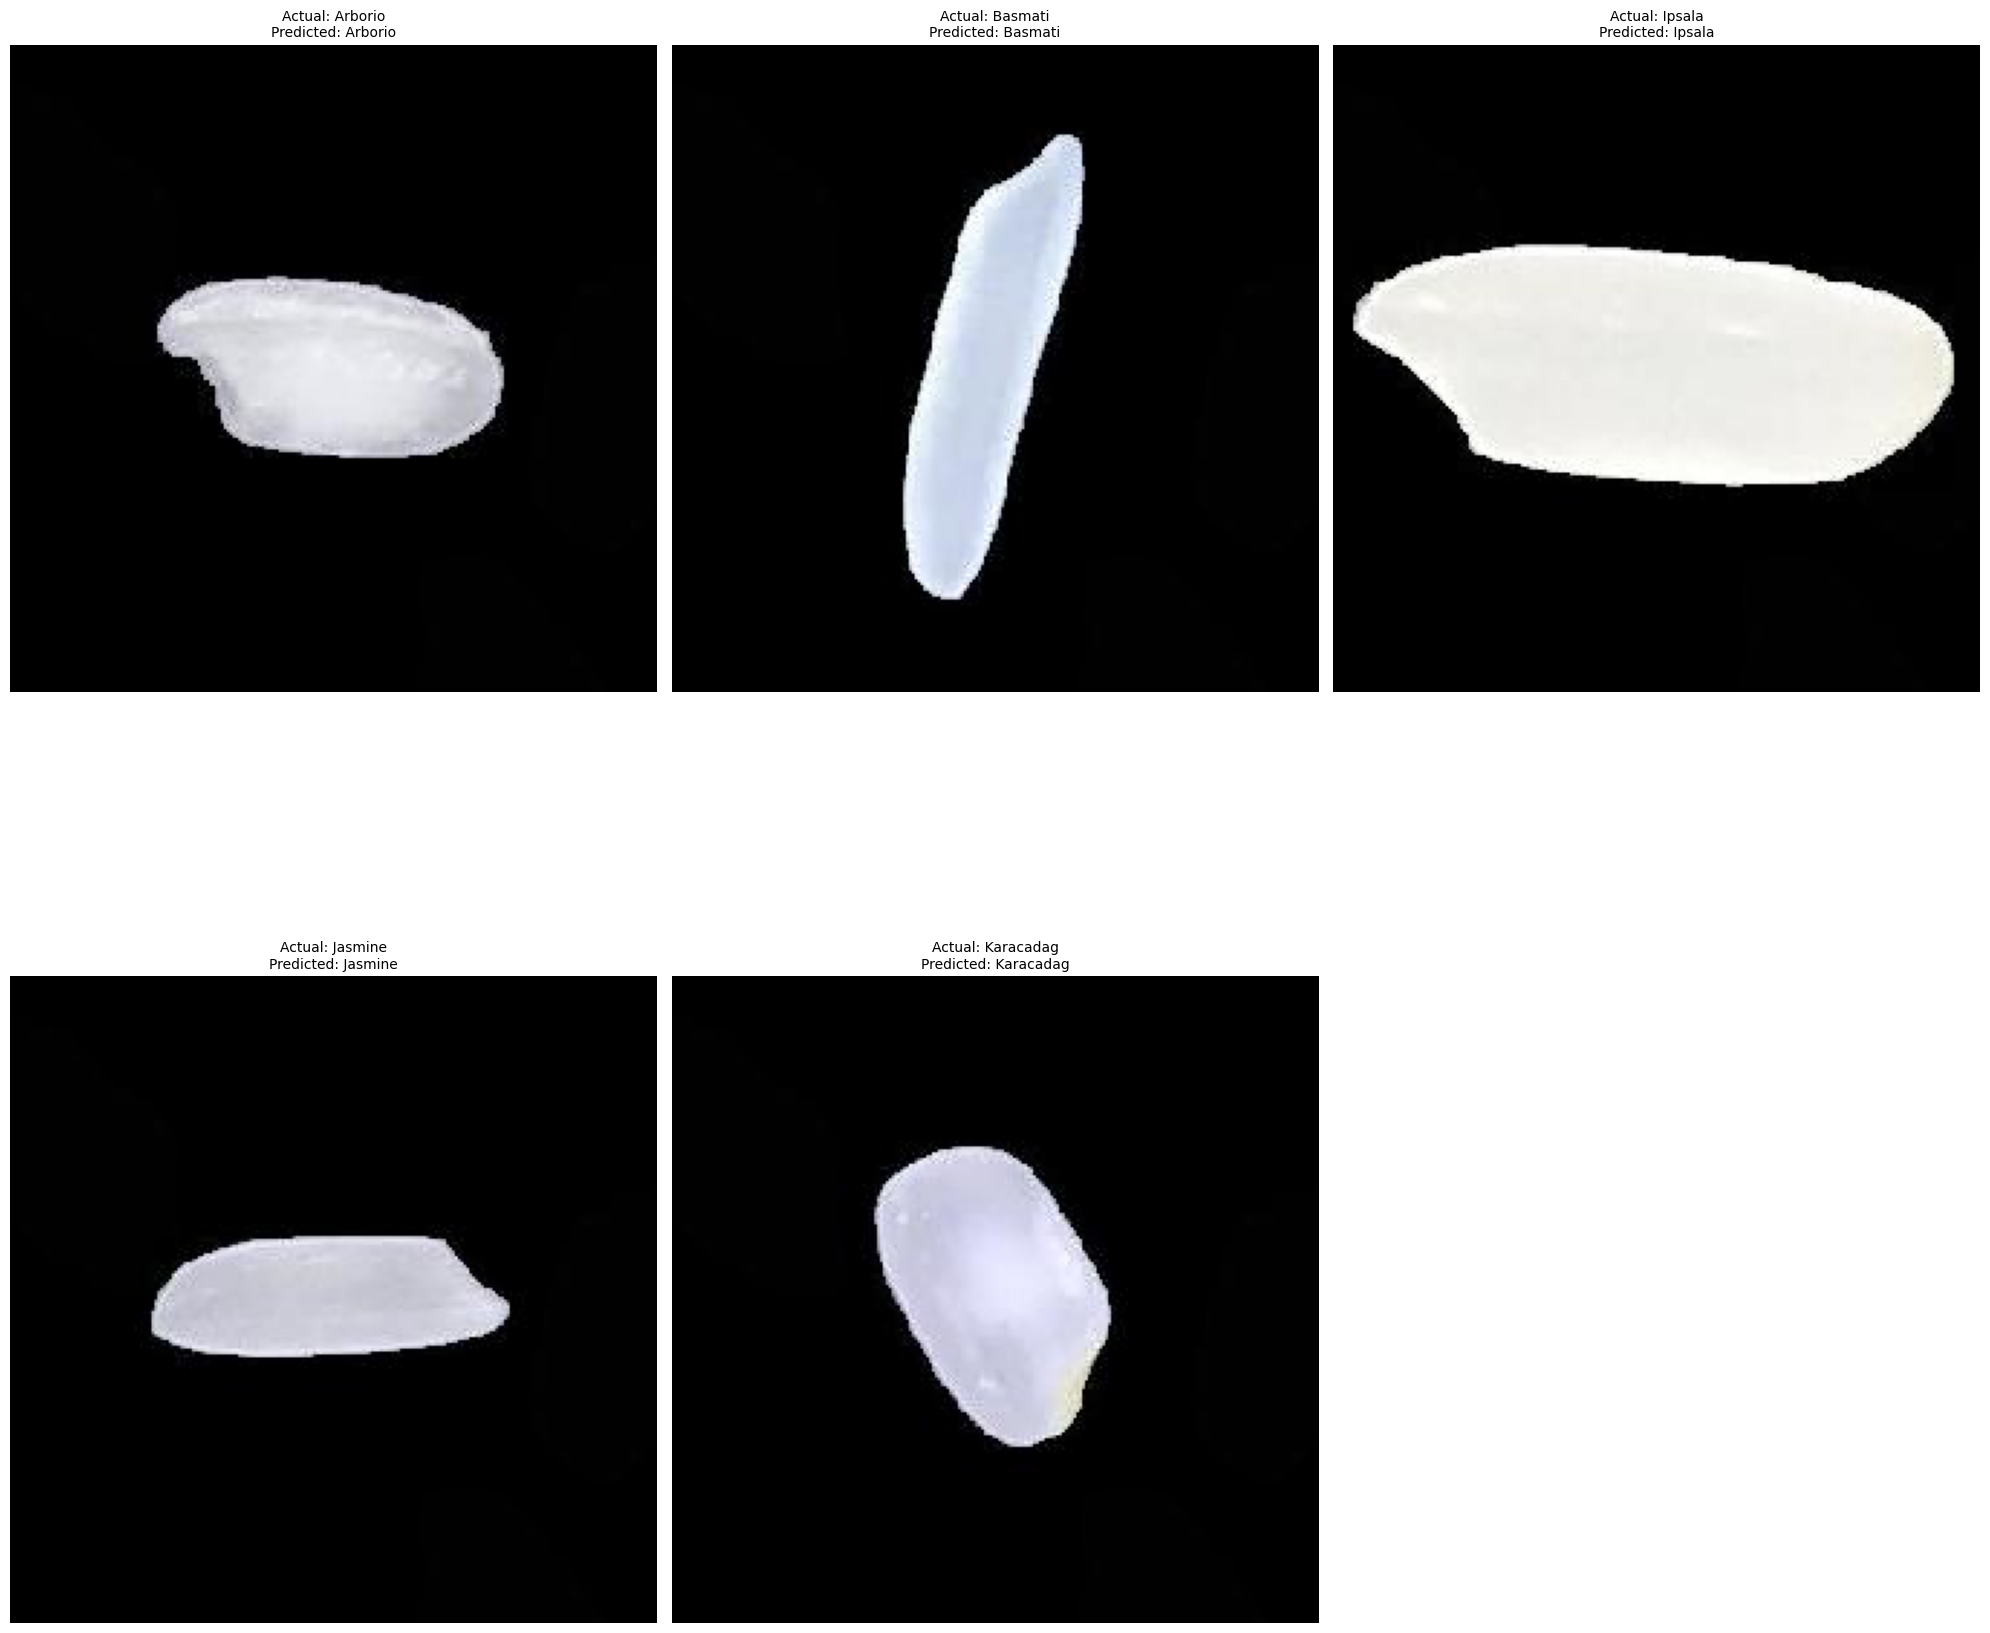

In [58]:
import numpy as np
import matplotlib.pyplot as plt

val_gen.reset()

x_all = []
y_all = []

for i in range(len(val_gen)):
    x_batch, y_batch = val_gen[i]
    x_all.append(x_batch)
    y_all.append(y_batch)

x_all = np.vstack(x_all)
y_all = np.vstack(y_all)

class_names = list(val_gen.class_indices.keys())
num_classes = len(class_names)

plt.figure(figsize=(20, 20))

for class_id in range(num_classes):
    idx = np.where(np.argmax(y_all, axis=1) == class_id)[0][0]

    img_display = (x_all[idx] + 1) / 2
    img_display = np.clip(img_display, 0, 1)

    prediction = model.predict(np.expand_dims(x_all[idx], axis=0), verbose=0)
    predicted_label = np.argmax(prediction)

    plt.subplot(2, 3, class_id + 1)
    plt.imshow(img_display)
    plt.title(
        f"Actual: {class_names[class_id]}\nPredicted: {class_names[predicted_label]}",
        fontsize=10
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Model Performance Comparison & Conclusion**

In this project, two deep learning architectures were trained and evaluated for the classification of five distinct rice varieties: **Arborio**, **Basmati**, **Ipsala**, **Jasmine**, and **Karacadag**.

#### **Key Results:**
* **Transfer Learning (MobileNetV2):** Achieved an exceptional overall accuracy of **99.49%**.
* **Custom CNN Architecture:** Achieved a competitive overall accuracy of **98.56%**.

#### **Discussion:**
Both models demonstrated high effectiveness in distinguishing between the subtle morphological differences among the five rice grain types. However, the Transfer Learning approach using MobileNetV2 outperformed the custom CNN model, improving overall test accuracy by nearly **0.93 percentage points**. 

Leveraging pre-trained features from ImageNet allowed MobileNetV2 to capture richer spatial hierarchies and fine-grained visual features (such as grain aspect ratio, edge contours, and surface texture) more effectively, while requiring fewer training epochs to converge.

#### **Conclusion:**
The Transfer Learning model (MobileNetV2) is selected as the final deployed model due to its superior accuracy of **99.49%** and robust generalization performance across all 5 target classes.